In [ ]:
!pip install pytrends matplotlib pandas seaborn plotly

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq
import warnings
warnings.filterwarnings("ignore")

# **Setup pytrends library and keywords define**

In [ ]:
pytrends = TrendReq(hl = 'en-US' , tz = 360)
keyword = 'data science'

# **Data Reuqest**

In [ ]:
pytrends.build_payload([keyword] , cat = 0 , timeframe = 'today 12-m',geo = '',gprop='')

In [ ]:
# @title
pytrends.build_payload([keyword] , cat = 0 , timeframe = 'today 5-y' , geo='' , gprop= '')

# **Country Wise Interest**

In [ ]:
region_data = pytrends.interest_by_region()
region_data = region_data.sort_values(by = keyword , ascending = False).head(15)


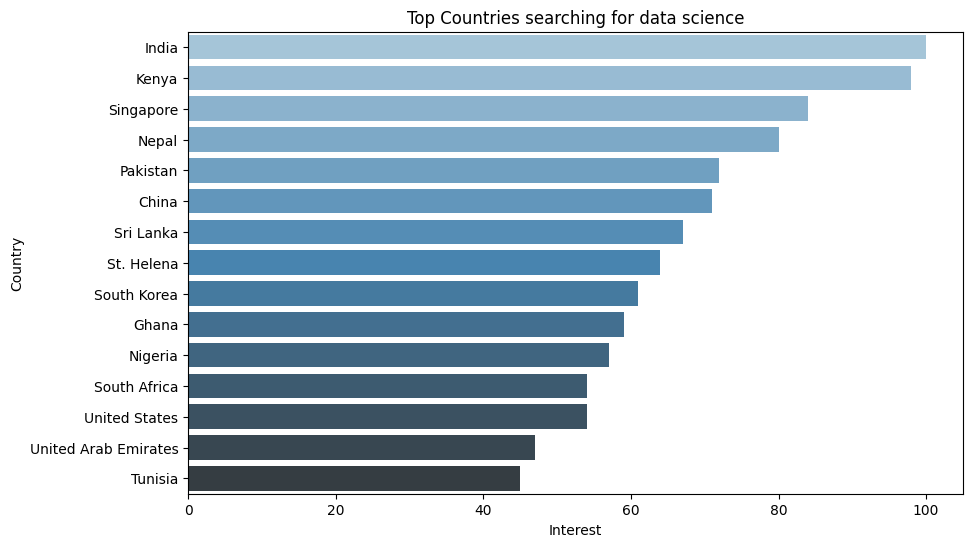

In [ ]:
plt.figure(figsize = (10,6))
sns.barplot(x = region_data[keyword] , y = region_data.index ,data = region_data  , palette= "Blues_d")
plt.title(f'Top Countries searching for {keyword}')
plt.xlabel('Interest')
plt.ylabel('Country')
plt.show()

# **World Map**

In [ ]:
region_data = region_data.reset_index()
fig = px.choropleth(region_data,
                    locations='geoName',
                    locationmode = 'country names',
                    color= keyword,
                    title = f'<b>Search Interest for {keyword} by country</b>',
                    color_continuous_scale=  'Blues',
                    width=1500,
                    height=600 )
fig.show()

# **Time Wise Interest**

In [ ]:
time_df = pytrends.interest_over_time()

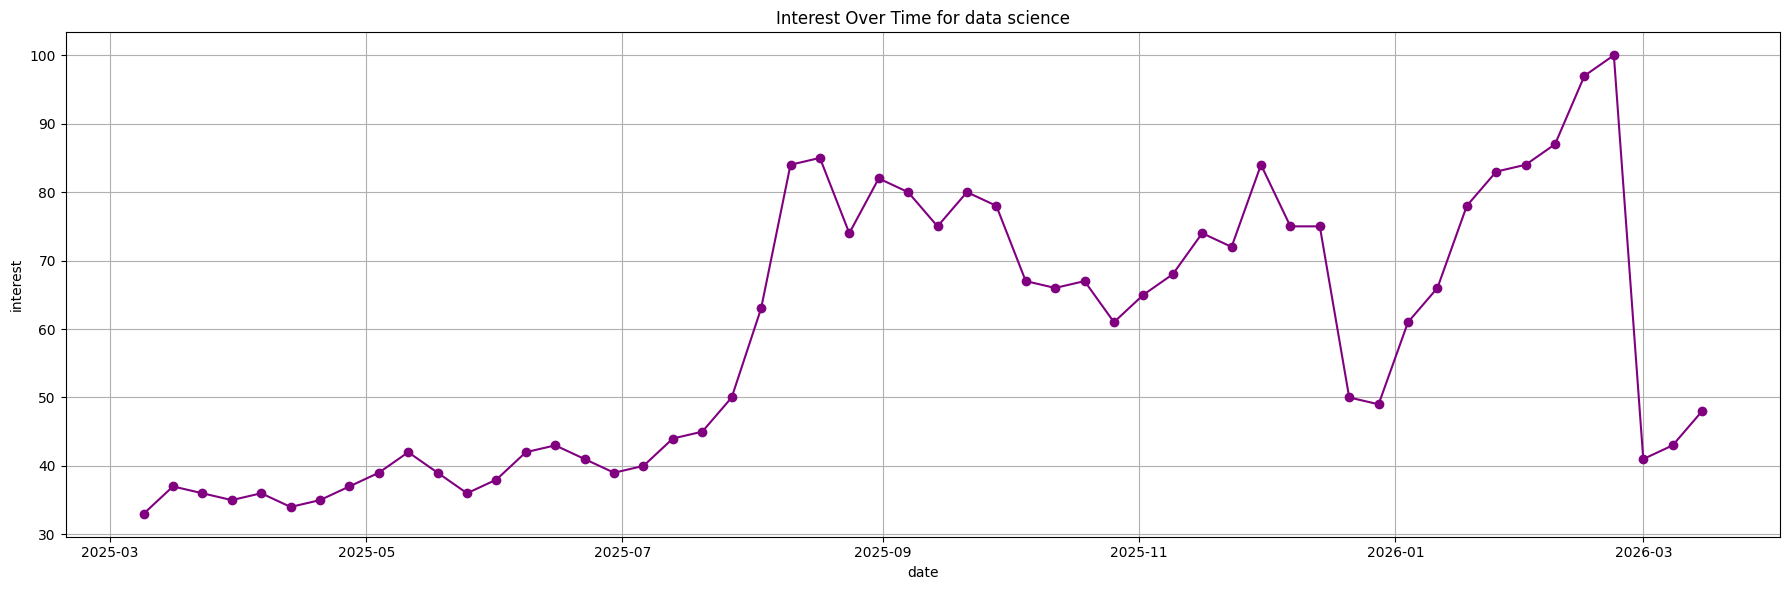

In [ ]:
plt.figure(figsize = (18,6))
plt.plot(time_df.index , time_df[keyword] , marker ='o' , color = 'purple')
plt.title(f'Interest Over Time for {keyword}')
plt.xlabel("date")
plt.ylabel("interest")
plt.grid(True)
plt.tight_layout()
plt.show()

# **Multiple keywords compare**

In [ ]:
kw_list = ['data science', 'machine learning' , 'data analytics' ]
pytrends.build_payload(kw_list , cat=0,timeframe='today 12-m',geo='',gprop='')

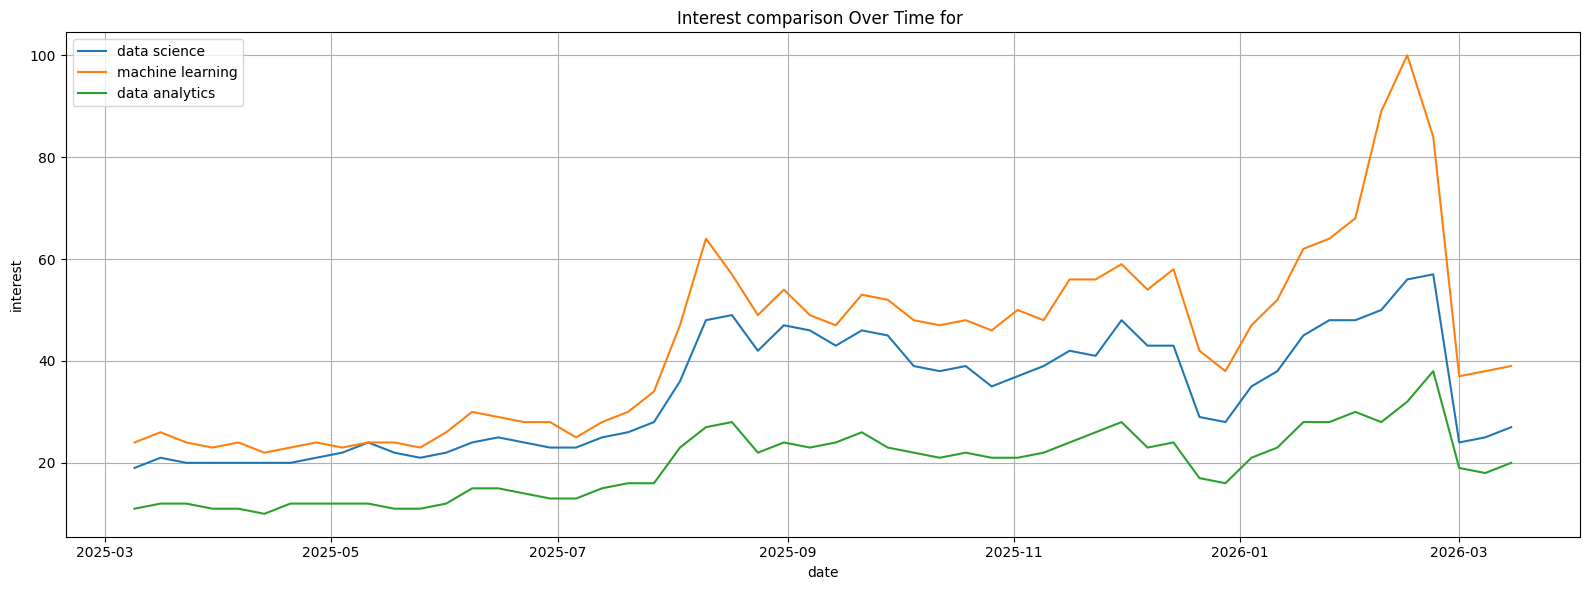

In [ ]:
compare_df = pytrends.interest_over_time()


plt.figure(figsize = (16,6))
for kw in kw_list:
  plt.plot(compare_df.index , compare_df[kw] , label = kw)

plt.title(f'Interest comparison Over Time for ')
plt.xlabel("date")
plt.ylabel("interest")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()